In [1]:
import os
import numpy as np
import mlatom as ml
from collections import defaultdict
from ase.io import read, write
from matplotlib import pyplot as plt
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm

In [2]:
N_STATES = 3

def prepare_molecular_database(xyz_filepath):
    database = []
    for atoms in read(xyz_filepath, index=":"):
        mol = ml.data.molecule.from_numpy(
            coordinates=atoms.get_positions() * ml.constants.Angstrom2Bohr, species=atoms.get_atomic_numbers()
        )
        mol.electronic_states = [mol.copy() for ii in range(N_STATES)]
        for i in range(N_STATES):
            mol.electronic_states[i].energy = (
                atoms.info[f"S{i}_energy"] * ml.constants.eV2hartree
            )
            mol.electronic_states[i].energy_gradients = (
                -atoms.arrays[f"S{i}_forces"] * ml.constants.eV2hartree / ml.constants.Angstrom2Bohr
            )
        database.append(mol)
    database = ml.data.molecular_database(database)
    return database



#os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [3]:
database_train = prepare_molecular_database("../../dataset_x/x_with_forces_0K+5000K+ci_v2_multistate_train.xyz")
database_val = prepare_molecular_database("../../dataset_x/x_with_forces_0K+5000K+ci_v2_multistate_val.xyz")
database_test = prepare_molecular_database("../../dataset_x/x_with_forces_0K+5000K+ci_v2_multistate_test.xyz")

In [30]:
model = ml.models.msani(nstates=3)
model.train(
    molecular_database=database_train,
    property_to_learn="energy",
    validation_molecular_database=database_val,
    xyz_derivative_property_to_learn="energy_gradients",
    hyperparameters={"max_epochs": 50},
    save_model=False,
)

StateInputNet(
  (AEV_computer): AEVComputer()
  (network): ANIModel(
    (C): Sequential(
      (0): Linear(in_features=241, out_features=160, bias=True)
      (1): CELU(alpha=0.1)
      (2): Linear(in_features=160, out_features=128, bias=True)
      (3): CELU(alpha=0.1)
      (4): Linear(in_features=128, out_features=96, bias=True)
      (5): CELU(alpha=0.1)
      (6): Linear(in_features=96, out_features=1, bias=True)
    )
    (H): Sequential(
      (0): Linear(in_features=241, out_features=160, bias=True)
      (1): CELU(alpha=0.1)
      (2): Linear(in_features=160, out_features=128, bias=True)
      (3): CELU(alpha=0.1)
      (4): Linear(in_features=128, out_features=96, bias=True)
      (5): CELU(alpha=0.1)
      (6): Linear(in_features=96, out_features=1, bias=True)
    )
    (N): Sequential(
      (0): Linear(in_features=241, out_features=160, bias=True)
      (1): CELU(alpha=0.1)
      (2): Linear(in_features=160, out_features=128, bias=True)
      (3): CELU(alpha=0.1)
      (

epoch 1: 100%|██████████| 74/74 [00:04<00:00, 17.08it/s]


validation MSE: 0.04016271838918328 at epoch 2
learning_rate: 0.001


epoch 2: 100%|██████████| 74/74 [00:02<00:00, 28.38it/s]


validation MSE: 0.03311406949069351 at epoch 3
learning_rate: 0.001


...

epoch 48: 100%|██████████| 74/74 [00:02<00:00, 28.50it/s]


validation MSE: 0.013699041010113433 at epoch 49
learning_rate: 0.001


epoch 49: 100%|██████████| 74/74 [00:03<00:00, 23.64it/s]


validation MSE: 0.01345294778002426 at epoch 50
learning_rate: 0.001


epoch 50: 100%|██████████| 74/74 [00:02<00:00, 32.30it/s]


In [31]:
y_true = []
y_pred = []

for mol in database_test:
    y_true.append(mol.electronic_states[0].energy)
    model.predict(
        molecule=mol,
        nstates=3,
        current_state=0,
        calculate_energy=True,
        calculate_energy_gradients=True,
    )
    y_pred.append(mol.electronic_states[0].energy)

energy MAE: 64.22 meV / atom


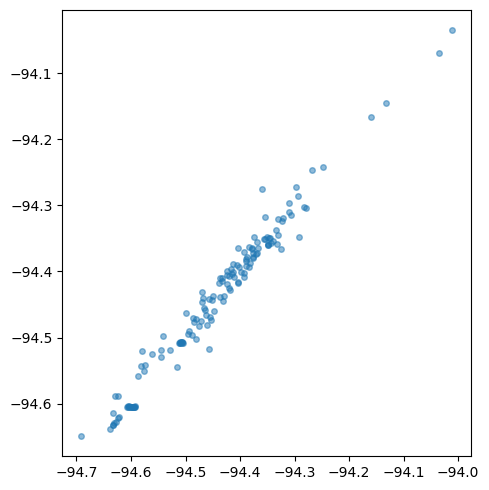

In [34]:
print(
    "energy MAE:",
    round(
        mean_absolute_error(y_true, y_pred) * ml.constants.Hartree2eV / 6*1000,
        3,
    ),
    "meV / atom",
)

plt.figure(figsize=(5.0, 5.0))
plt.scatter(y_true, y_pred, s=16, alpha=0.5)
plt.tight_layout()

energy MAE: 64.22 meV / atom


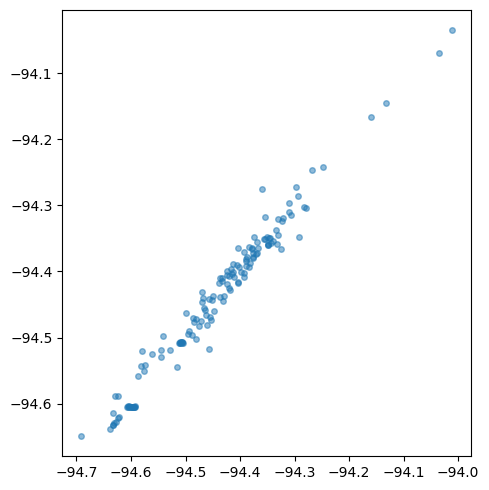

In [43]:
database_test = prepare_molecular_database("../../dataset_x/x_with_forces_0K+5000K+ci_v2_multistate_test.xyz")
y_true = []
y_pred = []

for mol in database_test:
    y_true.append(mol.electronic_states[0].energy)
    model.predict(
        molecule=mol,
        nstates=3,
        current_state=0,
        calculate_energy=True,
        calculate_energy_gradients=True,
    )
    y_pred.append(mol.electronic_states[0].energy)
print(
    "energy MAE:",
    round(
        mean_absolute_error(y_true, y_pred) * ml.constants.Hartree2eV / 6*1000,
        3,
    ),
    "meV / atom",
)

plt.figure(figsize=(5.0, 5.0))
plt.scatter(y_true, y_pred, s=16, alpha=0.5)
plt.tight_layout()    

energy MAE: 85.188 meV / atom


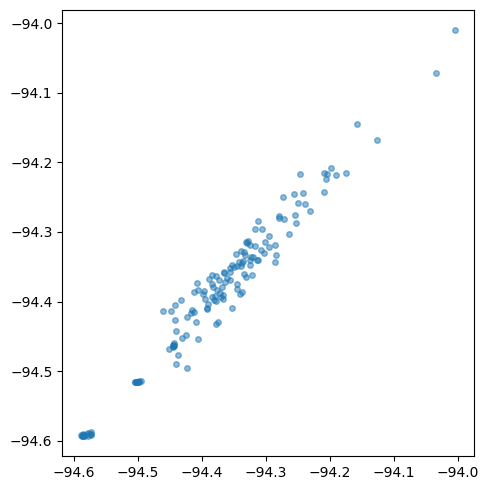

In [45]:
database_test = prepare_molecular_database("../../dataset_x/x_with_forces_0K+5000K+ci_v2_multistate_test.xyz")
y_true = []
y_pred = []

for mol in database_test:
    y_true.append(mol.electronic_states[1].energy)
    model.predict(
        molecule=mol,
        nstates=3,
        current_state=0,
        calculate_energy=True,
        calculate_energy_gradients=True,
    )
    y_pred.append(mol.electronic_states[1].energy)
print(
    "energy MAE:",
    round(
        mean_absolute_error(y_true, y_pred) * ml.constants.Hartree2eV / 6*1000,
        3,
    ),
    "meV / atom",
)

plt.figure(figsize=(5.0, 5.0))
plt.scatter(y_true, y_pred, s=16, alpha=0.5)
plt.tight_layout()    

In [63]:
database_test = prepare_molecular_database("../../dataset_x/x_with_forces_0K+5000K+ci_v2_multistate_test.xyz")
y_true = []
y_pred = []
y_true_f = []
y_pred_f = []

for mol in database_test:
    y_true.append(mol.electronic_states[0].energy)
    y_true_f.append(mol.electronic_states[0].energy_gradients)
    model.predict(
        molecule=mol,
        nstates=3,
        current_state=0,
        calculate_energy=True,
        calculate_energy_gradients=True,
    )
    y_pred.append(mol.electronic_states[0].energy)
    y_pred_f.append(mol.electronic_states[0].energy_gradients)
print(
    "energy MAE:",
    round(
        mean_absolute_error(y_true, y_pred) * ml.constants.Hartree2eV / 6*1000,
        3,
    ),
    "meV / atom",
)
print(
    "gradients MAE:",
    round(
        mean_absolute_error(np.array(y_true_f).flatten(), np.array(y_pred_f).flatten()) * ml.constants.Hartree2eV / ml.constants.Bohr2Angstrom*1000,
        3,
    ),
    "meV / A",
)
# plt.figure(figsize=(5.0, 5.0))
# plt.scatter(y_true, y_pred, s=16, alpha=0.5)
# plt.tight_layout()    

energy MAE: 47.556 meV / atom
gradients MAE: 646.511 meV / A


In [64]:
database_test = prepare_molecular_database("../../dataset_x/x_with_forces_0K+5000K+ci_v2_multistate_test.xyz")
y_true = []
y_pred = []
y_true_f = []
y_pred_f = []

for mol in database_test:
    y_true.append(mol.electronic_states[1].energy)
    y_true_f.append(mol.electronic_states[1].energy_gradients)
    model.predict(
        molecule=mol,
        nstates=3,
        current_state=0,
        calculate_energy=True,
        calculate_energy_gradients=True,
    )
    y_pred.append(mol.electronic_states[1].energy)
    y_pred_f.append(mol.electronic_states[1].energy_gradients)
print(
    "energy MAE:",
    round(
        mean_absolute_error(y_true, y_pred) * ml.constants.Hartree2eV / 6*1000,
        3,
    ),
    "meV / atom",
)
print(
    "gradients MAE:",
    round(
        mean_absolute_error(np.array(y_true_f).flatten(), np.array(y_pred_f).flatten()) * ml.constants.Hartree2eV / ml.constants.Bohr2Angstrom*1000,
        3,
    ),
    "meV / A",
)
# plt.figure(figsize=(5.0, 5.0))
# plt.scatter(y_true, y_pred, s=16, alpha=0.5)
# plt.tight_layout()    

energy MAE: 58.689 meV / atom
gradients MAE: 784.036 meV / A


In [65]:
database_test = prepare_molecular_database("../../dataset_x/x_with_forces_0K+5000K+ci_v2_multistate_test.xyz")
y_true = []
y_pred = []
y_true_f = []
y_pred_f = []

for mol in database_test:
    y_true.append(mol.electronic_states[2].energy)
    y_true_f.append(mol.electronic_states[2].energy_gradients)
    model.predict(
        molecule=mol,
        nstates=3,
        current_state=0,
        calculate_energy=True,
        calculate_energy_gradients=True,
    )
    y_pred.append(mol.electronic_states[2].energy)
    y_pred_f.append(mol.electronic_states[2].energy_gradients)
print(
    "energy MAE:",
    round(
        mean_absolute_error(y_true, y_pred) * ml.constants.Hartree2eV / 6*1000,
        3,
    ),
    "meV / atom",
)
print(
    "gradients MAE:",
    round(
        mean_absolute_error(np.array(y_true_f).flatten(), np.array(y_pred_f).flatten()) * ml.constants.Hartree2eV / ml.constants.Bohr2Angstrom*1000,
        3,
    ),
    "meV / A",
)
# plt.figure(figsize=(5.0, 5.0))
# plt.scatter(y_true, y_pred, s=16, alpha=0.5)
# plt.tight_layout()    

energy MAE: 44.399 meV / atom
gradients MAE: 757.872 meV / A


In [4]:
model = ml.models.msani(nstates=3)

In [5]:

model.train(
    molecular_database=database_train,
    property_to_learn="energy",
    validation_molecular_database=database_val,
    xyz_derivative_property_to_learn="energy_gradients",
    hyperparameters={"max_epochs": 500},
    save_model=True,
    use_last_model=False
)

StateInputNet(
  (AEV_computer): AEVComputer()
  (network): ANIModel(
    (C): Sequential(
      (0): Linear(in_features=241, out_features=160, bias=True)
      (1): CELU(alpha=0.1)
      (2): Linear(in_features=160, out_features=128, bias=True)
      (3): CELU(alpha=0.1)
      (4): Linear(in_features=128, out_features=96, bias=True)
      (5): CELU(alpha=0.1)
      (6): Linear(in_features=96, out_features=1, bias=True)
    )
    (H): Sequential(
      (0): Linear(in_features=241, out_features=160, bias=True)
      (1): CELU(alpha=0.1)
      (2): Linear(in_features=160, out_features=128, bias=True)
      (3): CELU(alpha=0.1)
      (4): Linear(in_features=128, out_features=96, bias=True)
      (5): CELU(alpha=0.1)
      (6): Linear(in_features=96, out_features=1, bias=True)
    )
    (N): Sequential(
      (0): Linear(in_features=241, out_features=160, bias=True)
      (1): CELU(alpha=0.1)
      (2): Linear(in_features=160, out_features=128, bias=True)
      (3): CELU(alpha=0.1)
      (

epoch 1: 100%|██████████| 74/74 [00:05<00:00, 13.71it/s]


validation MSE: 0.04025092418305576 at epoch 2
learning_rate: 0.001
model saved in ani_c8f5e1bb-4445-45a6-990b-ca3814edde48.pt


epoch 2: 100%|██████████| 74/74 [00:05<00:00, 13.70it/s]


validation MSE: 0.03184171294560656 at epoch 3
learning_rate: 0.001
model saved in ani_c8f5e1bb-4445-45a6-990b-ca3814edde48.pt


...

epoch 438: 100%|██████████| 74/74 [00:05<00:00, 13.92it/s]


validation MSE: 0.009534740878734738 at epoch 439
learning_rate: 0.00025


epoch 439: 100%|██████████| 74/74 [00:05<00:00, 13.97it/s]


validation MSE: 0.009528469003271312 at epoch 440
learning_rate: 0.00025


epoch 440:  16%|█▌        | 12/74 [00:00<00:04, 13.91it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [6]:
database_test = prepare_molecular_database("../../dataset_x/x_with_forces_0K+5000K+ci_v2_multistate_test.xyz")
y_true = []
y_pred = []
y_true_f = []
y_pred_f = []

for mol in database_test:
    y_true.append(mol.electronic_states[0].energy)
    y_true_f.append(mol.electronic_states[0].energy_gradients)
    model.predict(
        molecule=mol,
        nstates=3,
        current_state=0,
        calculate_energy=True,
        calculate_energy_gradients=True,
    )
    y_pred.append(mol.electronic_states[0].energy)
    y_pred_f.append(mol.electronic_states[0].energy_gradients)
print(
    "energy MAE:",
    round(
        mean_absolute_error(y_true, y_pred) * ml.constants.Hartree2eV / 6*1000,
        3,
    ),
    "meV / atom",
)
print(
    "gradients MAE:",
    round(
        mean_absolute_error(np.array(y_true_f).flatten(), np.array(y_pred_f).flatten()) * ml.constants.Hartree2eV / ml.constants.Bohr2Angstrom*1000,
        3,
    ),
    "meV / A",
)
# plt.figure(figsize=(5.0, 5.0))
# plt.scatter(y_true, y_pred, s=16, alpha=0.5)
# plt.tight_layout()    

energy MAE: 51.664 meV / atom
gradients MAE: 723.133 meV / A


energy MAE: 56.044 meV / atom
gradients MAE: 831.839 meV / A


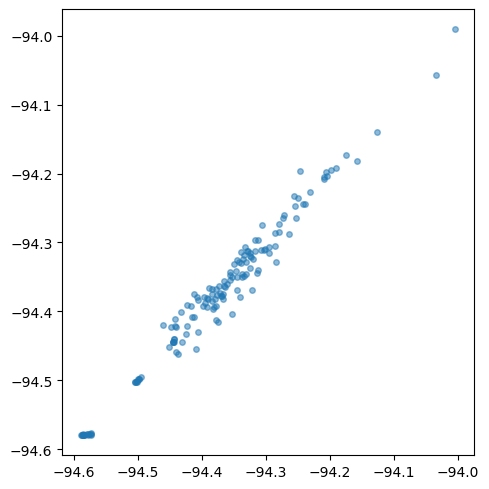

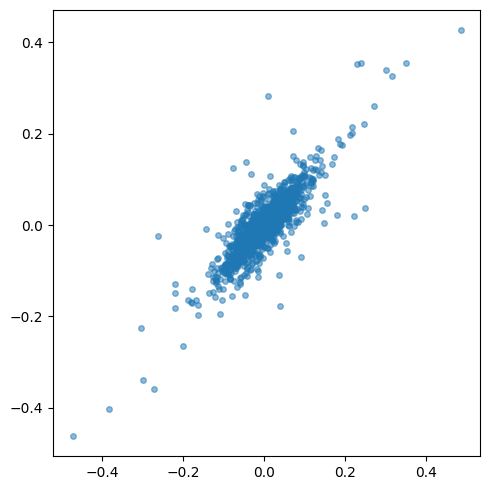

In [7]:
database_test = prepare_molecular_database("../../dataset_x/x_with_forces_0K+5000K+ci_v2_multistate_test.xyz")
y_true = []
y_pred = []
y_true_f = []
y_pred_f = []

for mol in database_test:
    y_true.append(mol.electronic_states[1].energy)
    y_true_f.append(mol.electronic_states[1].energy_gradients)
    model.predict(
        molecule=mol,
        nstates=3,
        current_state=0,
        calculate_energy=True,
        calculate_energy_gradients=True,
    )
    y_pred.append(mol.electronic_states[1].energy)
    y_pred_f.append(mol.electronic_states[1].energy_gradients)
print(
    "energy MAE:",
    round(
        mean_absolute_error(y_true, y_pred) * ml.constants.Hartree2eV / 6*1000,
        3,
    ),
    "meV / atom",
)
print(
    "gradients MAE:",
    round(
        mean_absolute_error(np.array(y_true_f).flatten(), np.array(y_pred_f).flatten()) * ml.constants.Hartree2eV / ml.constants.Bohr2Angstrom*1000,
        3,
    ),
    "meV / A",
)
plt.figure(figsize=(5.0, 5.0))
plt.scatter(y_true, y_pred, s=16, alpha=0.5)
plt.tight_layout()    
plt.figure(figsize=(5.0, 5.0))
plt.scatter(np.array(y_true_f).flatten(), np.array(y_pred_f).flatten(), s=16, alpha=0.5)
plt.tight_layout()  
plt.show()

energy MAE: 41.509 meV / atom
gradients MAE: 810.96 meV / A


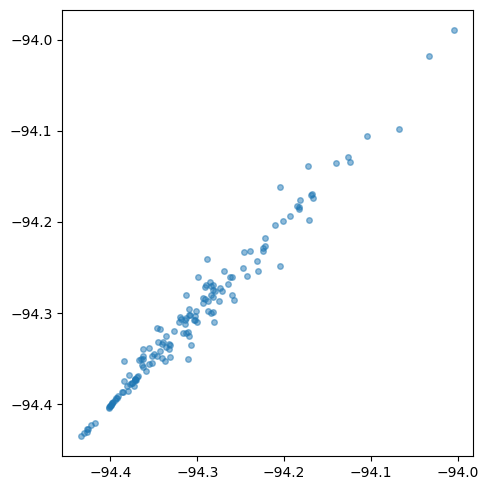

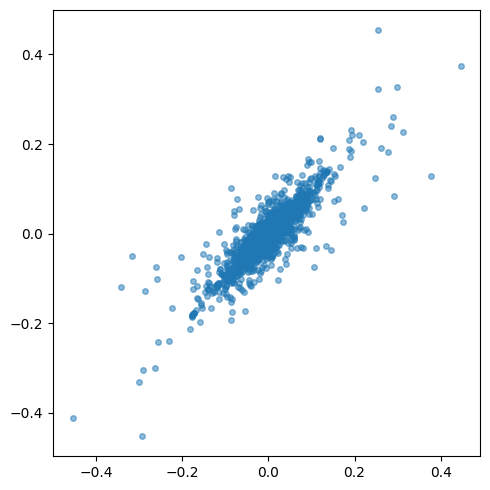

In [8]:
database_test = prepare_molecular_database("../../dataset_x/x_with_forces_0K+5000K+ci_v2_multistate_test.xyz")
y_true = []
y_pred = []
y_true_f = []
y_pred_f = []

for mol in database_test:
    y_true.append(mol.electronic_states[2].energy)
    y_true_f.append(mol.electronic_states[2].energy_gradients)
    model.predict(
        molecule=mol,
        nstates=3,
        current_state=0,
        calculate_energy=True,
        calculate_energy_gradients=True,
    )
    y_pred.append(mol.electronic_states[2].energy)
    y_pred_f.append(mol.electronic_states[2].energy_gradients)
print(
    "energy MAE:",
    round(
        mean_absolute_error(y_true, y_pred) * ml.constants.Hartree2eV / 6*1000,
        3,
    ),
    "meV / atom",
)
print(
    "gradients MAE:",
    round(
        mean_absolute_error(np.array(y_true_f).flatten(), np.array(y_pred_f).flatten()) * ml.constants.Hartree2eV / ml.constants.Bohr2Angstrom*1000,
        3,
    ),
    "meV / A",
)
plt.figure(figsize=(5.0, 5.0))
plt.scatter(y_true, y_pred, s=16, alpha=0.5)
plt.tight_layout()    
plt.figure(figsize=(5.0, 5.0))
plt.scatter(np.array(y_true_f).flatten(), np.array(y_pred_f).flatten(), s=16, alpha=0.5)
plt.tight_layout()  
plt.show()